# Lab 8 – Play Tennis Classification

Comparing **Categorical Naive Bayes**, **Decision Tree**, and **Logistic Regression** on the Play Tennis dataset.

In [ ]:
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder, OneHotEncoder
from sklearn.naive_bayes import CategoricalNB
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams['figure.dpi'] = 110
COLORS = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']
print('Libraries loaded OK')

Libraries loaded OK


## 1  Load Data

In [ ]:
df = pd.read_csv('Lab 8 - Sheet1.csv').drop(columns=['No'])
print('Shape:', df.shape)
df.head()

Shape: (50, 5)


,Outlook,Temperature,Humidity,Wind,Play Tennis
0,Sunny,Hot,High,Weak,No
1,Sunny,Hot,High,Strong,No
2,Overcast,Hot,High,Weak,Yes
3,Rain,Mild,High,Weak,Yes
4,Rain,Cool,Normal,Weak,Yes


## 2  Class Distribution

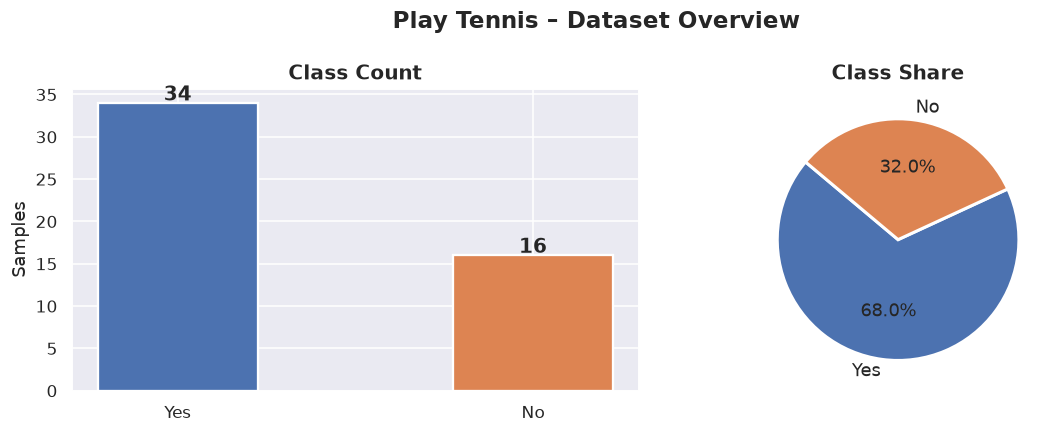

In [ ]:
counts = df['Play Tennis'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

bars = axes[0].bar(counts.index, counts.values, color=COLORS[:2],
                   edgecolor='white', linewidth=1.5, width=0.45)
for b in bars:
    axes[0].text(b.get_x() + b.get_width()/2, b.get_height() + 0.3,
                 int(b.get_height()), ha='center', fontweight='bold', fontsize=13)
axes[0].set_title('Class Count', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Samples')

axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=COLORS[:2], startangle=140,
            wedgeprops=dict(edgecolor='white', linewidth=2),
            textprops={'fontsize': 12})
axes[1].set_title('Class Share', fontsize=13, fontweight='bold')

fig.suptitle('Play Tennis – Dataset Overview', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## 3  Feature Distribution by Class

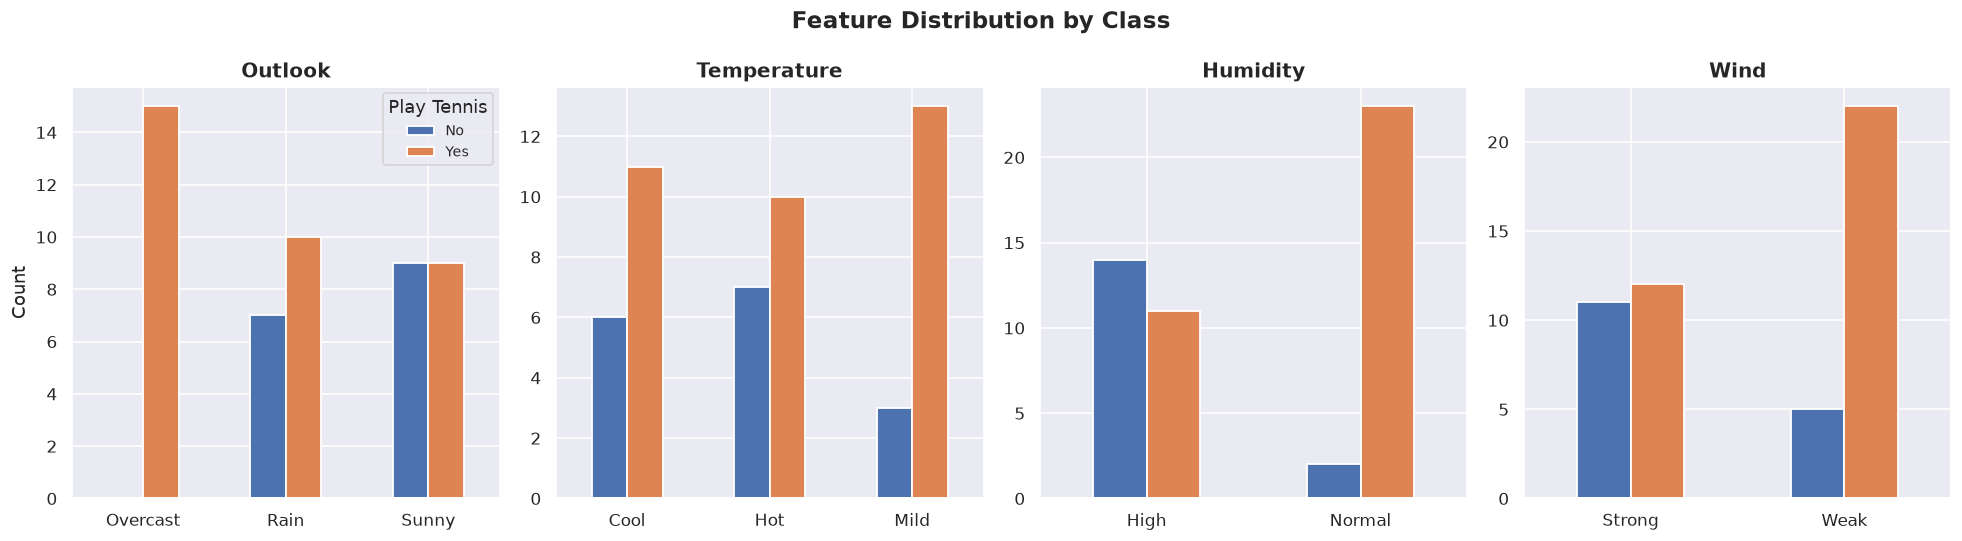

In [ ]:
features = ['Outlook', 'Temperature', 'Humidity', 'Wind']
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

for ax, feat in zip(axes, features):
    ct = df.groupby([feat, 'Play Tennis']).size().unstack(fill_value=0)
    ct.plot(kind='bar', ax=ax, color=COLORS[:2],
            edgecolor='white', linewidth=1.2, rot=0,
            legend=(feat == 'Outlook'))
    ax.set_title(feat, fontsize=13, fontweight='bold')
    ax.set_xlabel('')
    if feat == 'Outlook':
        ax.set_ylabel('Count')
        ax.legend(title='Play Tennis', fontsize=9)

fig.suptitle('Feature Distribution by Class', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## 4  Encode & Split

In [ ]:
X = df.drop(columns=['Play Tennis'])
y = df['Play Tennis']

enc = OrdinalEncoder()
X_enc = enc.fit_transform(X)

le = LabelEncoder()
y_enc = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X_enc, y_enc, test_size=0.30, random_state=42, stratify=y_enc)

print(f'Train: {len(X_train)}  |  Test: {len(X_test)}')
print('Classes:', le.classes_)

Train: 35  |  Test: 15
Classes: ['No' 'Yes']


## 5  Train All Models

In [ ]:
nb = CategoricalNB()
nb.fit(X_train, y_train)
y_pred_nb = nb.predict(X_test)
acc_nb = accuracy_score(y_test, y_pred_nb)

dt = DecisionTreeClassifier(random_state=42, max_depth=4)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
acc_dt = accuracy_score(y_test, y_pred_dt)

preprocessor = ColumnTransformer([('ohe', OneHotEncoder(), list(range(X.shape[1])))])
lr = make_pipeline(preprocessor, LogisticRegression(max_iter=300, solver='lbfgs'))
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
acc_lr = accuracy_score(y_test, y_pred_lr)

print(f'Naive Bayes        : {acc_nb:.2f}')
print(f'Decision Tree      : {acc_dt:.2f}')
print(f'Logistic Regression: {acc_lr:.2f}')

Naive Bayes        : 0.87
Decision Tree      : 0.93
Logistic Regression: 0.93


## 6  Classification Reports

In [ ]:
for name, preds in [('Naive Bayes', y_pred_nb),
                    ('Decision Tree', y_pred_dt),
                    ('Logistic Regression', y_pred_lr)]:
    print(f'=== {name} ===')
    print(classification_report(y_test, preds, target_names=le.classes_))

=== Naive Bayes ===
              precision    recall  f1-score   support

          No       1.00      0.60      0.75         5
         Yes       0.83      1.00      0.91        10

    accuracy                           0.87        15
   macro avg       0.92      0.80      0.83        15
weighted avg       0.89      0.87      0.86        15

=== Decision Tree ===
              precision    recall  f1-score   support

          No       0.83      1.00      0.91         5
         Yes       1.00      0.90      0.95        10

    accuracy                           0.93        15
   macro avg       0.92      0.95      0.93        15
weighted avg       0.94      0.93      0.93        15

=== Logistic Regression ===
              precision    recall  f1-score   support

          No       1.00      0.80      0.89         5
         Yes       0.91      1.00      0.95        10

    accuracy                           0.93        15
   macro avg       0.95      0.90      0.92        15
weig

## 7  Confusion Matrices

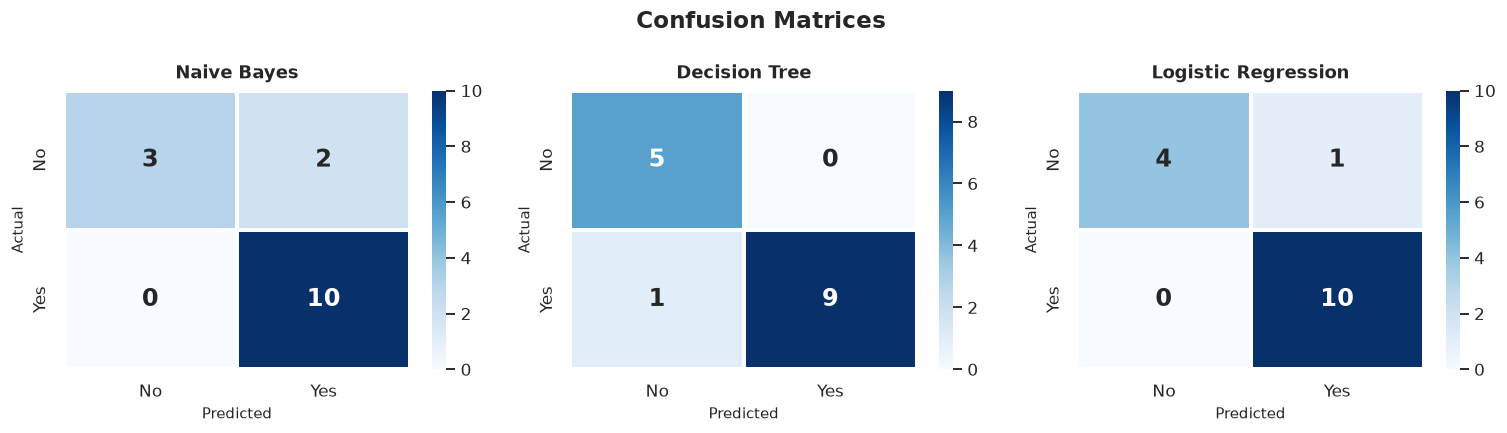

In [ ]:
model_names = ['Naive Bayes', 'Decision Tree', 'Logistic Regression']
all_preds   = [y_pred_nb, y_pred_dt, y_pred_lr]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, name, preds in zip(axes, model_names, all_preds):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=le.classes_, yticklabels=le.classes_,
                linewidths=1.5, linecolor='white', ax=ax,
                annot_kws={'size': 16, 'weight': 'bold'})
    ax.set_title(name, fontsize=12, fontweight='bold', pad=8)
    ax.set_xlabel('Predicted', fontsize=10)
    ax.set_ylabel('Actual', fontsize=10)

fig.suptitle('Confusion Matrices', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## 8  Accuracy Comparison

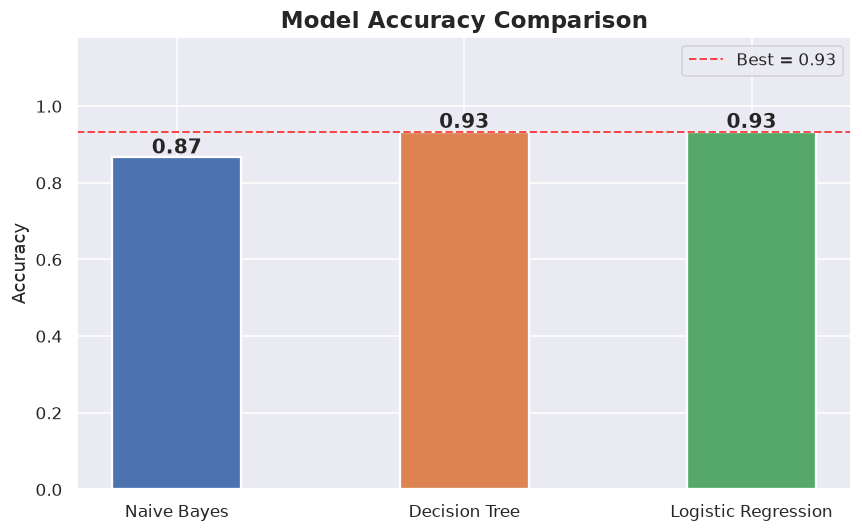

In [ ]:
accs = [acc_nb, acc_dt, acc_lr]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(model_names, accs, color=COLORS[:3],
              edgecolor='white', linewidth=1.5, width=0.45)
for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.01,
            f'{acc:.2f}', ha='center', fontsize=13, fontweight='bold')
ax.set_ylim(0, 1.18)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Model Accuracy Comparison', fontsize=15, fontweight='bold')
ax.axhline(max(accs), color='red', linestyle='--', linewidth=1.3,
           alpha=0.7, label=f'Best = {max(accs):.2f}')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

## 9  Decision Tree Visualisation

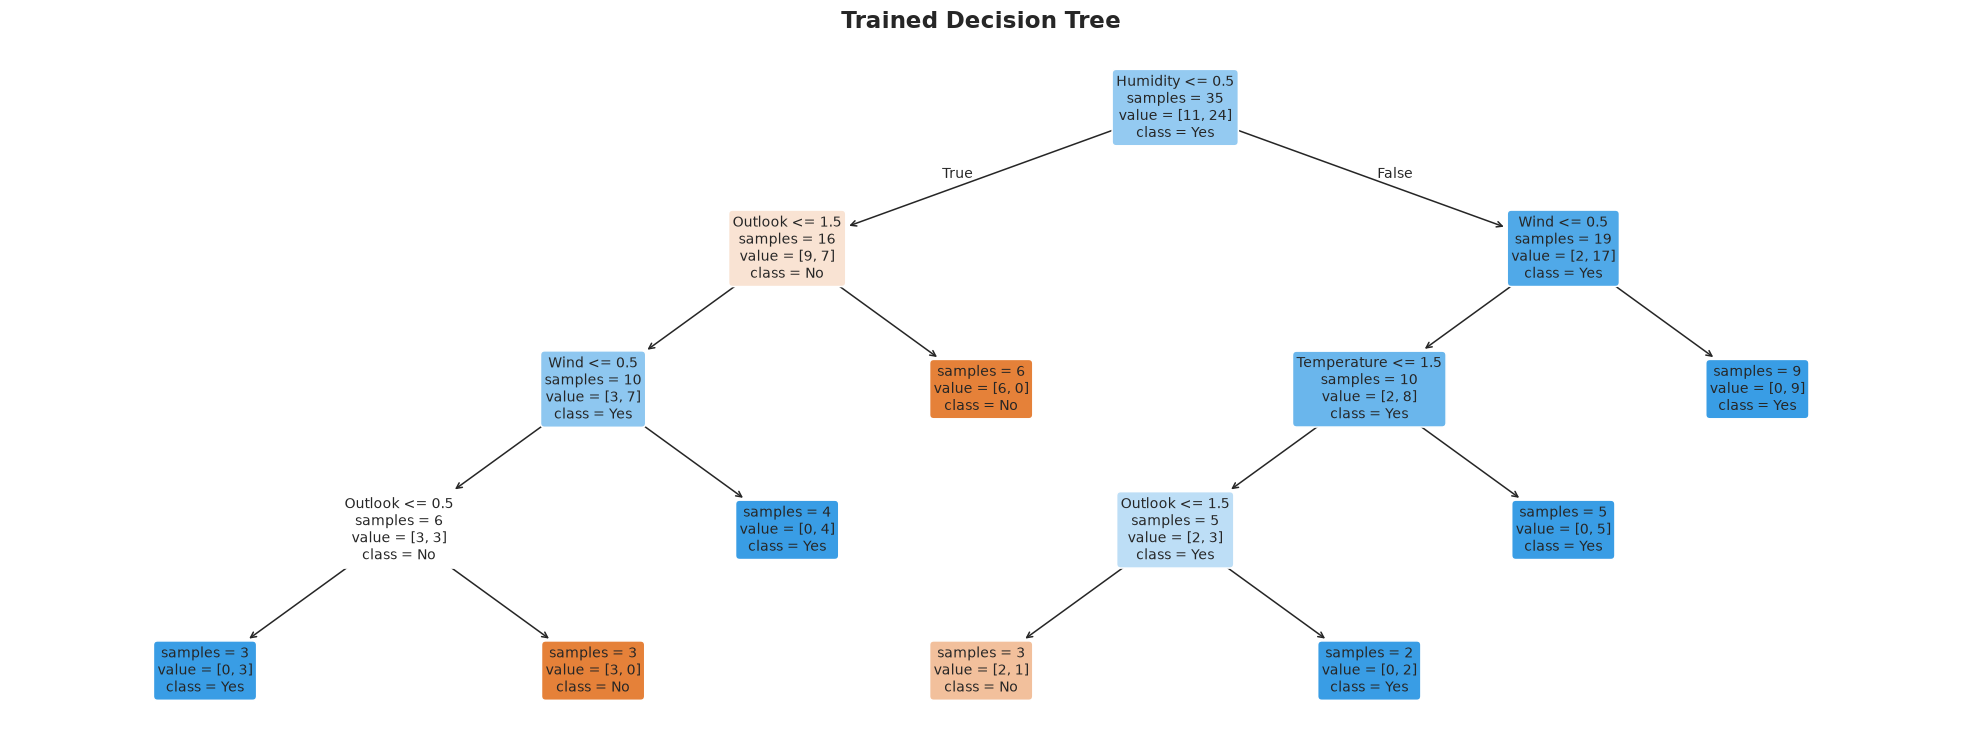

In [ ]:
fig, ax = plt.subplots(figsize=(18, 7))
plot_tree(dt, feature_names=X.columns.tolist(),
          class_names=le.classes_,
          filled=True, rounded=True, fontsize=9,
          impurity=False, ax=ax)
ax.set_title('Trained Decision Tree', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## 10  Predict New Weather Condition

| Feature | Value |
|---|---|
| Outlook | Sunny |
| Temperature | Cool |
| Humidity | High |
| Wind | Strong |

Predicted class : No
  P(No) = 0.7466
  P(Yes) = 0.2534


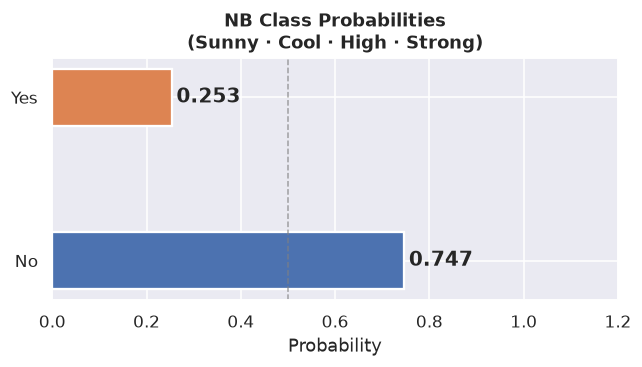

In [ ]:
new_input = pd.DataFrame({'Outlook':['Sunny'],'Temperature':['Cool'],
                          'Humidity':['High'],'Wind':['Strong']})
new_enc_val = enc.transform(new_input)

pred_label = le.inverse_transform(nb.predict(new_enc_val))[0]
probs      = nb.predict_proba(new_enc_val)[0]

print(f'Predicted class : {pred_label}')
for cls, p in zip(le.classes_, probs):
    print(f'  P({cls}) = {p:.4f}')

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.barh(le.classes_, probs, color=COLORS[:2],
        edgecolor='white', linewidth=1.5, height=0.35)
for i, (cls, p) in enumerate(zip(le.classes_, probs)):
    ax.text(p + 0.01, i, f'{p:.3f}', va='center', fontsize=13, fontweight='bold')
ax.set_xlim(0, 1.2)
ax.set_xlabel('Probability', fontsize=12)
ax.set_title('NB Class Probabilities\n(Sunny · Cool · High · Strong)',
             fontsize=12, fontweight='bold')
ax.axvline(0.5, color='grey', linestyle='--', linewidth=1, alpha=0.7)
plt.tight_layout()
plt.show()